# Scratch ViT Interpretability Visualization

This notebook visualizes interpretability heatmaps for the custom scratch ViT baseline.

It supports:
- single-layer CLS attention heatmaps
- attention rollout heatmaps

It does not use Grad-CAM.

Attention rollout and single-layer attention do not require retraining.
They only require a trained checkpoint and forward passes that return attention weights.


In [1]:
from pathlib import Path
import sys
import math

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

REPO_ROOT = Path("..").resolve()
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from train import load_config, merge_dicts, resolve_device
from models import build_model
from data import build_nih_data_module
from interpretability import build_cls_attention_heatmap

plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["axes.titlesize"] = 11


In [2]:
BASE_CONFIG = REPO_ROOT / "configs/vit_baseline.yaml"
CHECKPOINT_PATH = REPO_ROOT / "artifacts/experiments/final_vit_baseline_fixed/checkpoints/vit_best_auc.pt"
# CHECKPOINT_PATH = REPO_ROOT / "artifacts/experiments/final_vit_baseline_fixed_smoke/checkpoints/vit_best_auc.pt"

SPLIT = "val"  # "val" or "test"

MAX_BATCHES_TO_SCAN = 5
MAX_SAMPLES_TO_SHOW = 8

LAYER_INDEX = -1
HEAD_REDUCTION = "mean"  # "mean" or "max"

ROLLOUT_HEAD_REDUCTION = "mean"
ROLLOUT_DISCARD_RATIO = 0.0


In [3]:
import os

# Go up one level from notebooks/ to project root
os.chdir('..')

# Verify
print(os.getcwd())  # Should end in visiontrans_diagnostics

/home/nate/Documents/omscs/dl/final_project/visiontrans_diagnostics


In [4]:
# Load the resolved config from the checkpoint, then build the model/data module.
if not BASE_CONFIG.exists():
    raise FileNotFoundError(f"Base config not found: {BASE_CONFIG}")
if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"Checkpoint not found: {CHECKPOINT_PATH}")
 

base_config = load_config(BASE_CONFIG)
checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
checkpoint_config = checkpoint.get("config", {})
config = merge_dicts(base_config, checkpoint_config)

device = resolve_device(config)


print(config)
data_module = build_nih_data_module(config)

if SPLIT not in data_module["dataloaders"]:
    raise ValueError(f"Requested split={SPLIT}, but available splits are {list(data_module['dataloaders'])}")

data_loader = data_module["dataloaders"][SPLIT]
label_names = list(data_module["labels"])

model = build_model(config).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

data_config = config.get("data", {})
model_config = config.get("model", {})

image_size = int(data_config.get("image_size", 224))
patch_size = int(model_config.get("patch_size", 16))
num_channels = int(data_config.get("num_channels", 1))
mean = tuple(float(v) for v in data_config.get("normalize_mean", [0.5]))
std = tuple(float(v) for v in data_config.get("normalize_std", [0.25]))

print("Device:", device)
print("Checkpoint:", CHECKPOINT_PATH)
print("Split:", SPLIT)
print("Labels:", label_names)
print("Image size:", image_size)
print("Patch size:", patch_size)
print("Num channels:", num_channels)
print("Train/val/test loaders:", list(data_module["dataloaders"].keys()))
print("Model:", model.__class__.__name__)


{'project': {'name': 'visiontrans_diagnostics', 'seed': 42, 'device': 'auto'}, 'data': {'dataset': 'nih_chest_xray', 'raw_dir': 'data/raw', 'annotations_dir': 'data/annotations', 'processed_dir': 'data/processed', 'manifest_dir': 'data/manifests', 'train_manifest': 'data/manifests/train.csv', 'val_manifest': 'data/manifests/val.csv', 'test_manifest': 'data/manifests/test.csv', 'image_size': 224, 'num_channels': 1, 'num_classes': 14, 'batch_size': 32, 'num_workers': 4, 'val_fraction': 0.1, 'pos_weight_clamp': 50, 'augmentation': {'enabled': True, 'allow_horizontal_flip': True, 'horizontal_flip_prob': 0.5, 'rotation_degrees': 10, 'color_jitter_brightness': 0.2, 'color_jitter_contrast': 0.2, 'crop_type': 'none', 'crop_scale': None}, 'normalize_mean': [0.5], 'normalize_std': [0.25]}, 'training': {'epochs': 40, 'optimizer': 'adamw', 'learning_rate': 0.0001, 'weight_decay': 0.0001, 'loss': 'focal', 'use_amp': True, 'use_pos_weight': False, 'focal_gamma': 2.0, 'focal_alpha': 0.25, 'scheduler'

In [5]:
# Visualization helpers.
def denormalize_image(image_tensor, mean, std):
    image = image_tensor.detach().cpu().clone().float()
    for channel_index, (channel_mean, channel_std) in enumerate(zip(mean, std)):
        image[channel_index] = image[channel_index] * channel_std + channel_mean
    image = image.clamp(0.0, 1.0).numpy()
    if image.shape[0] == 1:
        image = np.repeat(image, 3, axis=0)
    image = np.transpose(image, (1, 2, 0))
    return image


def overlay_heatmap(image_array, heatmap, alpha=0.35):
    image = np.asarray(image_array, dtype=np.float32).copy()
    if image.max() > 1.0:
        image = image / 255.0
    if isinstance(heatmap, torch.Tensor):
        heatmap_array = heatmap.detach().cpu().squeeze().numpy()
    else:
        heatmap_array = np.asarray(heatmap).squeeze()
    heatmap_array = np.clip(heatmap_array, 0.0, 1.0)
    heatmap_rgb = plt.cm.inferno(heatmap_array)[..., :3]
    overlay = (1.0 - alpha) * image + alpha * heatmap_rgb
    return np.clip(overlay, 0.0, 1.0)


def plot_heatmap_triplet(image_array, single_layer_heatmap, rollout_heatmap, title=None):
    original = np.asarray(image_array, dtype=np.float32)
    single_overlay = overlay_heatmap(original, single_layer_heatmap)
    rollout_overlay = overlay_heatmap(original, rollout_heatmap)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(original)
    axes[0].set_title("Original")
    axes[1].imshow(single_overlay)
    axes[1].set_title("Single-layer CLS")
    axes[2].imshow(rollout_overlay)
    axes[2].set_title("Attention rollout")
    for axis in axes:
        axis.axis("off")
    if title:
        fig.suptitle(title)
    fig.tight_layout()
    return fig, axes


def get_top_labels(logits, label_names, k=5):
    probabilities = torch.sigmoid(logits.detach().cpu().flatten())
    top_k = min(k, probabilities.numel())
    values, indices = torch.topk(probabilities, k=top_k)
    return [(label_names[int(index)], float(value)) for value, index in zip(values, indices)]


In [6]:
# Attention rollout helpers for the custom ViT attention format.
def compute_attention_rollout(attn_maps, head_reduction="mean", discard_ratio=0.0):
    if not attn_maps:
        raise ValueError("attn_maps is empty. Call the model with return_attention=True first.")
    if not (0.0 <= discard_ratio < 1.0):
        raise ValueError("discard_ratio must be in [0.0, 1.0).")

    rollout = None
    for layer_index, attention in enumerate(attn_maps):
        if attention.ndim != 4:
            raise ValueError(
                f"Layer {layer_index} expected shape (B, num_heads, seq_len, seq_len), got {tuple(attention.shape)}"
            )

        layer_attention = attention.float()
        if head_reduction == "mean":
            reduced = layer_attention.mean(dim=1)
        elif head_reduction == "max":
            reduced = layer_attention.max(dim=1).values
        else:
            raise ValueError(f"Unsupported head_reduction '{head_reduction}'. Expected 'mean' or 'max'.")

        batch_size, seq_len, seq_len_2 = reduced.shape
        if seq_len != seq_len_2:
            raise ValueError(f"Attention layer {layer_index} must be square, got {tuple(reduced.shape)}")

        if discard_ratio > 0.0 and seq_len > 1:
            body = reduced[:, 1:, 1:].clone()
            flat_body = body.reshape(batch_size, -1)
            num_discard = int(flat_body.size(1) * discard_ratio)
            if num_discard > 0:
                _, discard_indices = torch.topk(flat_body, k=num_discard, dim=1, largest=False)
                filtered_body = flat_body.clone()
                filtered_body.scatter_(1, discard_indices, 0.0)
                reduced = reduced.clone()
                reduced[:, 1:, 1:] = filtered_body.reshape(batch_size, seq_len - 1, seq_len - 1)

        identity = torch.eye(seq_len, device=reduced.device, dtype=reduced.dtype).unsqueeze(0)
        augmented = reduced + identity
        augmented = augmented / augmented.sum(dim=-1, keepdim=True).clamp_min(1e-8)
        rollout = augmented if rollout is None else torch.bmm(augmented, rollout)

    return rollout


def rollout_to_heatmap(
    attn_maps,
    image_size,
    patch_size,
    head_reduction="mean",
    discard_ratio=0.0,
):
    if image_size % patch_size != 0:
        raise ValueError("image_size must be divisible by patch_size.")

    rollout = compute_attention_rollout(
        attn_maps,
        head_reduction=head_reduction,
        discard_ratio=discard_ratio,
    )
    batch_size, seq_len, seq_len_2 = rollout.shape
    if seq_len != seq_len_2:
        raise ValueError(f"Rollout matrix must be square, got {tuple(rollout.shape)}")

    grid_size = image_size // patch_size
    expected_num_patches = grid_size * grid_size
    cls_to_patches = rollout[:, 0, 1:]
    if cls_to_patches.size(-1) != expected_num_patches:
        raise ValueError(
            f"Expected {expected_num_patches} patch tokens, got {cls_to_patches.size(-1)}. "
            f"Check image_size={image_size} and patch_size={patch_size}."
        )

    patch_grid = cls_to_patches.reshape(batch_size, grid_size, grid_size)
    heatmap = F.interpolate(
        patch_grid.unsqueeze(1),
        size=(image_size, image_size),
        mode="bilinear",
        align_corners=False,
    )
    heatmap_min = heatmap.amin(dim=(2, 3), keepdim=True)
    heatmap_max = heatmap.amax(dim=(2, 3), keepdim=True)
    heatmap = (heatmap - heatmap_min) / (heatmap_max - heatmap_min).clamp_min(1e-8)
    return patch_grid, heatmap


In [7]:
# Take one batch from the requested split and compute both heatmap types.
batch = next(iter(data_loader))
images, labels = batch
images = images.to(device)

with torch.inference_mode():
    logits, attn_maps = model(images, return_attention=True)

attn_maps_cpu = [attention.detach().cpu() for attention in attn_maps]

_, single_layer_heatmaps = build_cls_attention_heatmap(
    attn_maps_cpu,
    image_size=image_size,
    patch_size=patch_size,
    layer_index=LAYER_INDEX,
    head_reduction=HEAD_REDUCTION,
)

_, rollout_heatmaps = rollout_to_heatmap(
    attn_maps_cpu,
    image_size=image_size,
    patch_size=patch_size,
    head_reduction=ROLLOUT_HEAD_REDUCTION,
    discard_ratio=ROLLOUT_DISCARD_RATIO,
)

dataset_frame = getattr(data_loader.dataset, "frame", None)
batch_frame = None
if dataset_frame is not None and SPLIT != "train":
    batch_frame = dataset_frame.iloc[: images.size(0)].reset_index(drop=True)

print("Images:", images.shape)
print("Logits:", logits.shape)
print("Number of attention layers:", len(attn_maps_cpu))
print("Attention layer 0 shape:", attn_maps_cpu[0].shape if attn_maps_cpu else None)
print("Single-layer heatmaps:", single_layer_heatmaps.shape)
print("Rollout heatmaps:", rollout_heatmaps.shape)


Images: torch.Size([16, 1, 224, 224])
Logits: torch.Size([16, 14])
Number of attention layers: 6
Attention layer 0 shape: torch.Size([16, 6, 197, 197])
Single-layer heatmaps: torch.Size([16, 1, 224, 224])
Rollout heatmaps: torch.Size([16, 1, 224, 224])


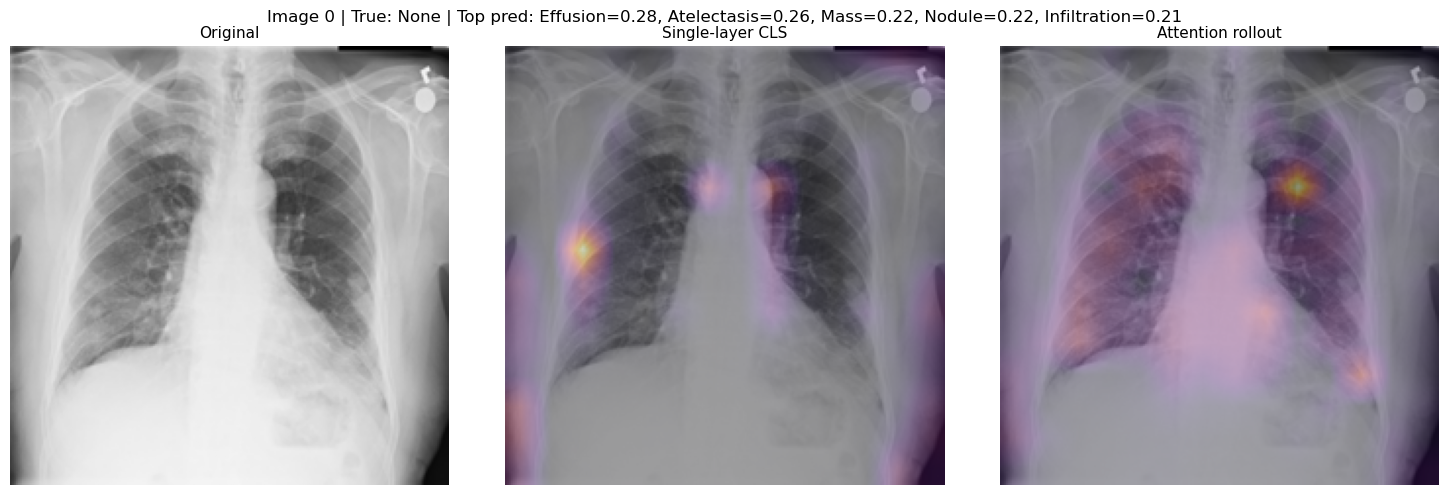

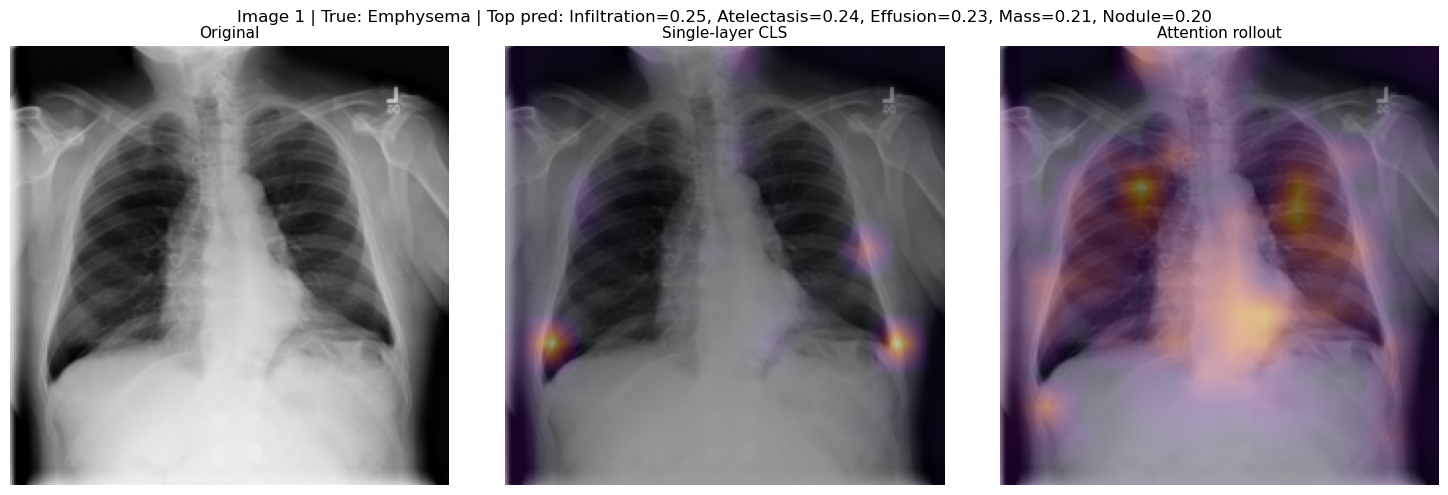

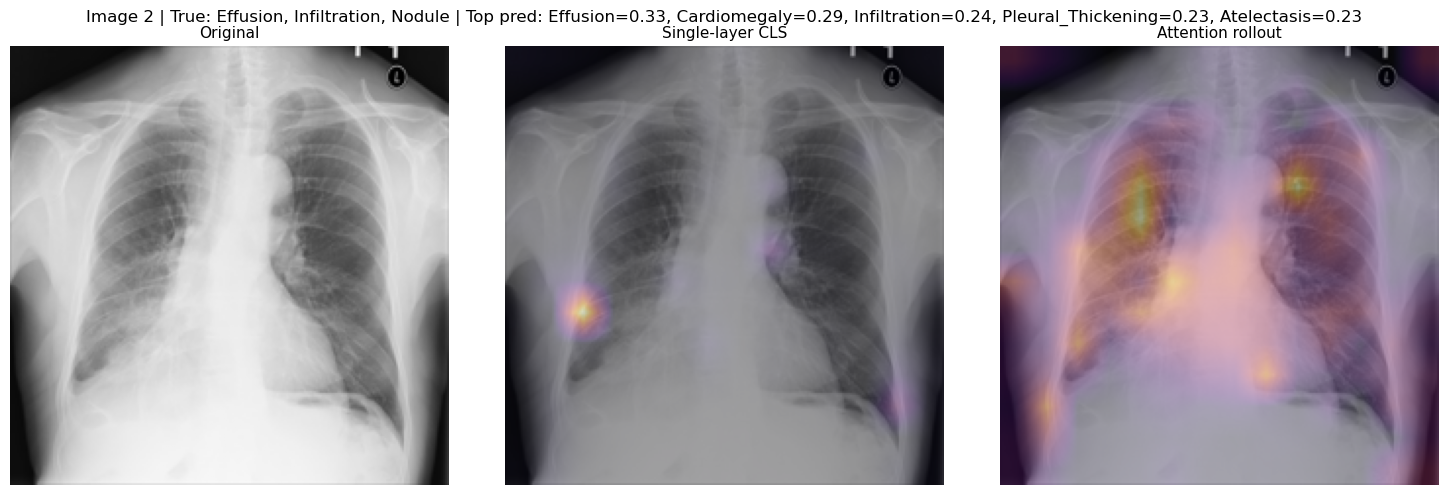

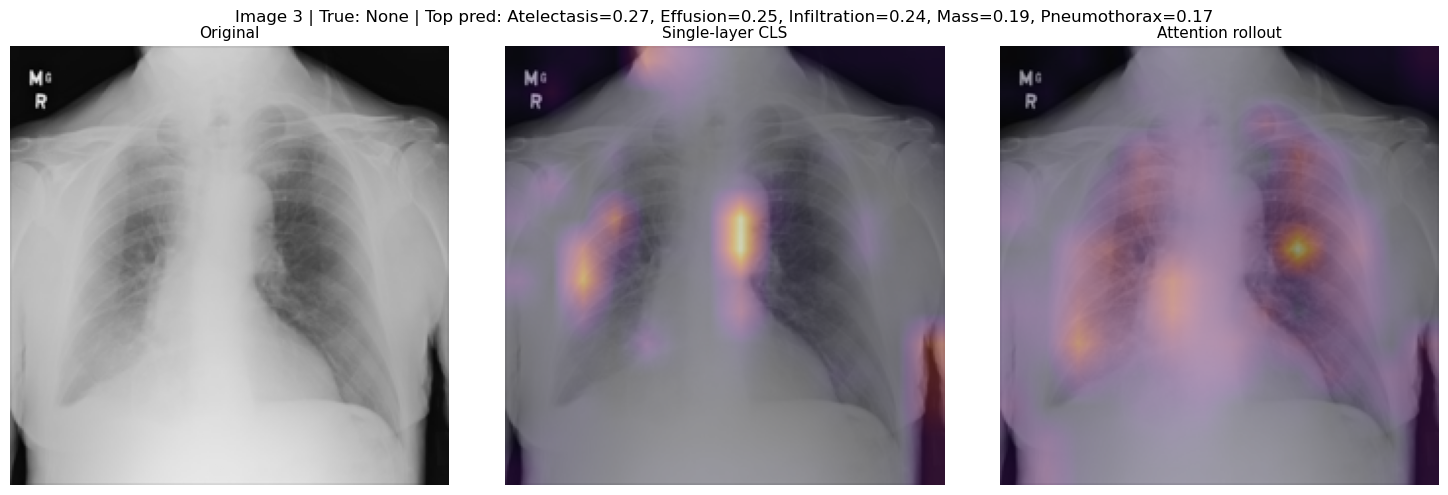

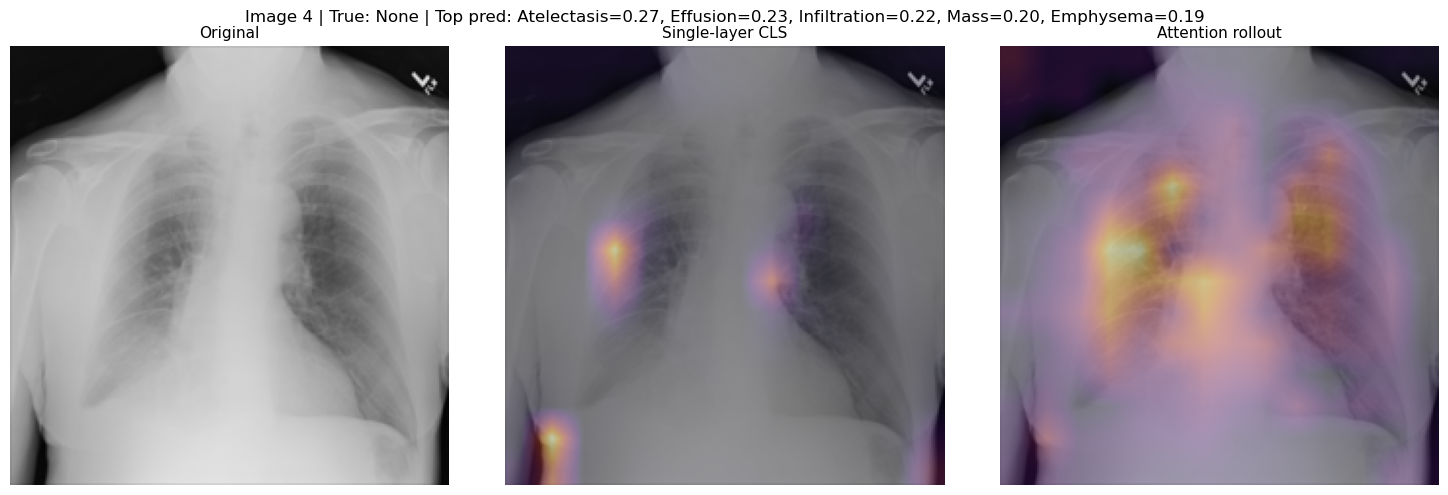

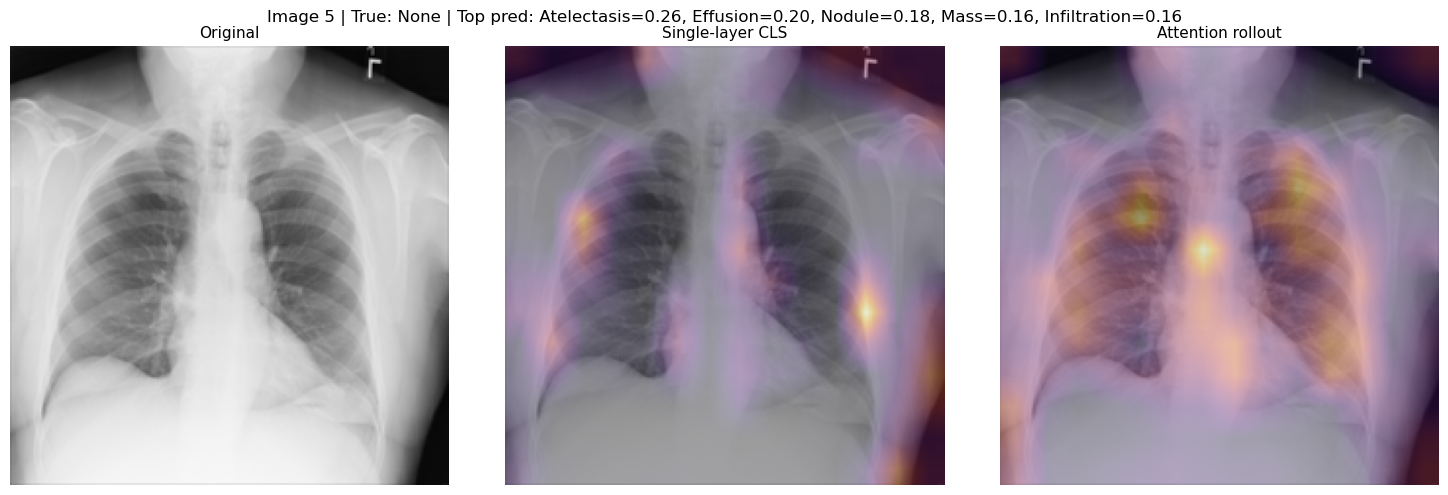

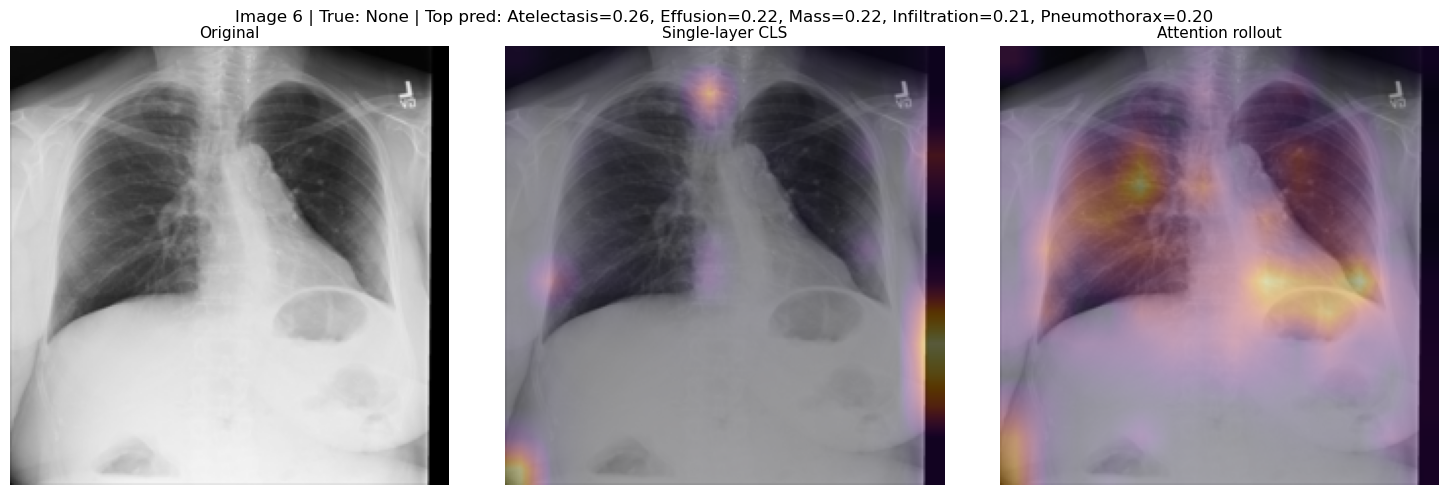

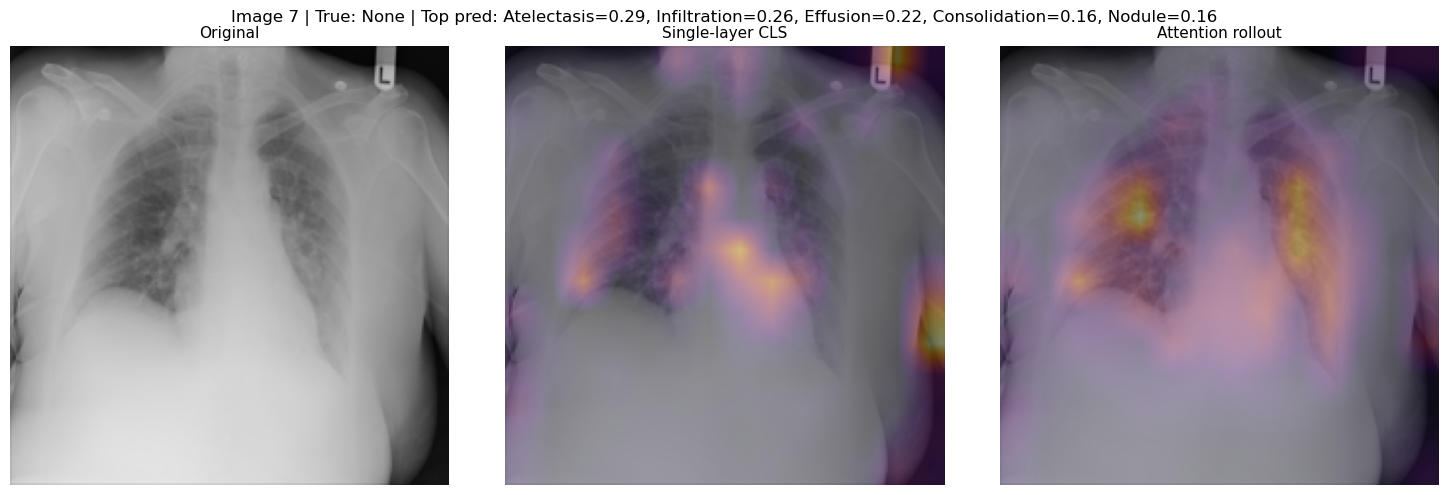

In [8]:
# Visualize the first N samples from the current batch.
probs = torch.sigmoid(logits.detach().cpu())
samples_to_show = min(MAX_SAMPLES_TO_SHOW, images.size(0))

for sample_index in range(samples_to_show):
    image_array = denormalize_image(images[sample_index].cpu(), mean, std)
    true_labels = [label_names[idx] for idx, value in enumerate(labels[sample_index].tolist()) if value > 0.5]
    true_label_text = ", ".join(true_labels) if true_labels else "None"
    top_predictions = get_top_labels(logits[sample_index], label_names, k=5)
    top_prediction_text = ", ".join(f"{name}={score:.2f}" for name, score in top_predictions)
    title = f"Image {sample_index} | True: {true_label_text} | Top pred: {top_prediction_text}"
    fig, _ = plot_heatmap_triplet(
        image_array,
        single_layer_heatmaps[sample_index],
        rollout_heatmaps[sample_index],
        title=title,
    )
    plt.show()


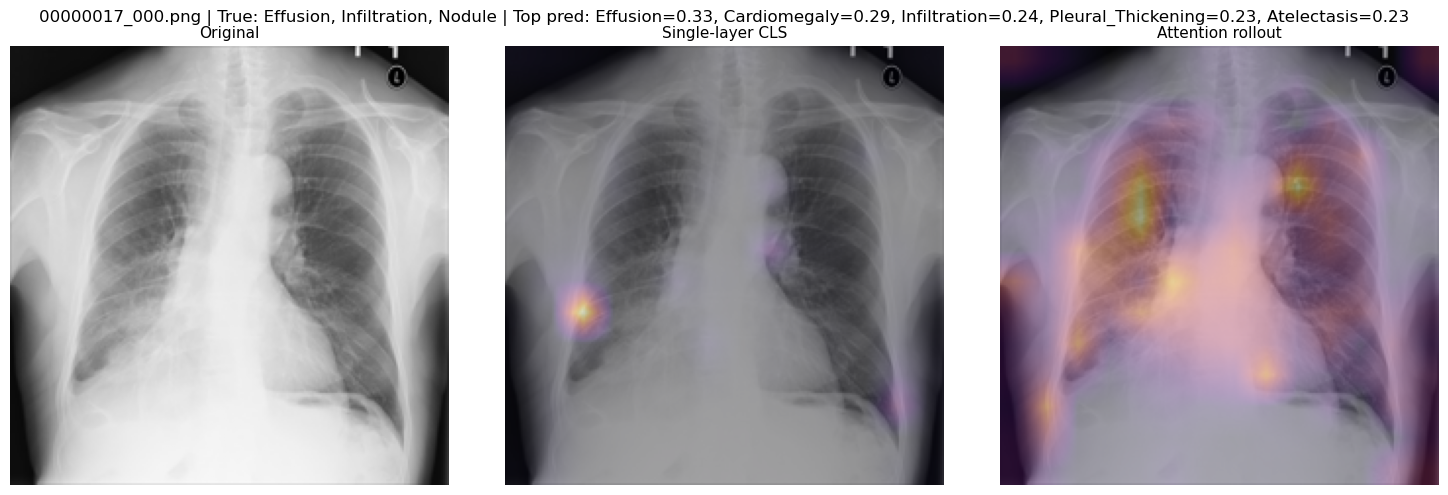

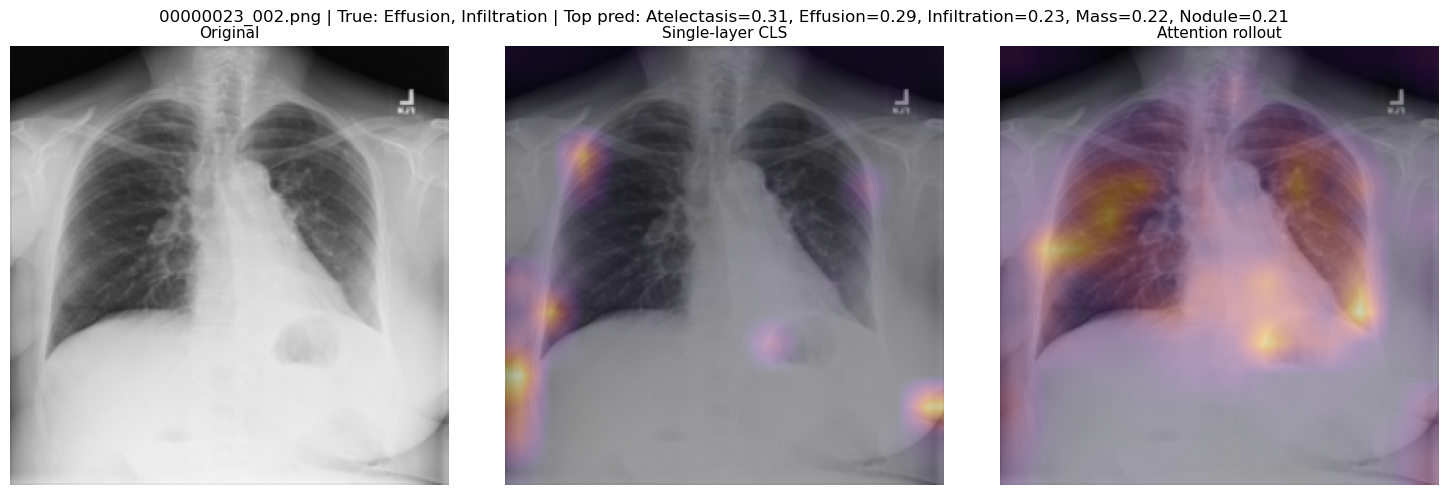

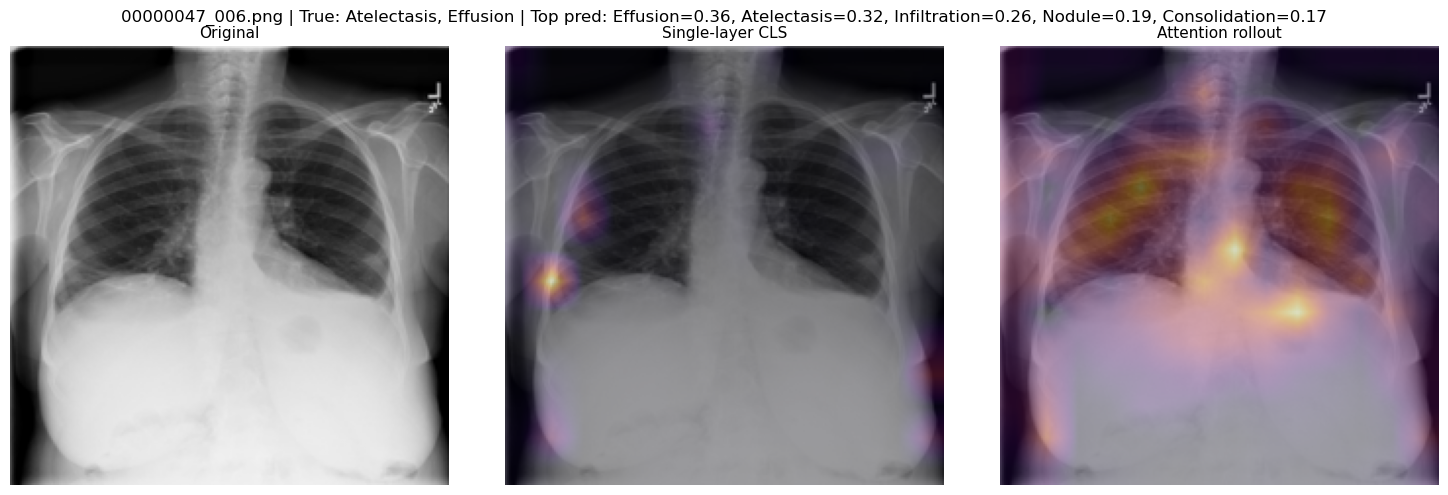

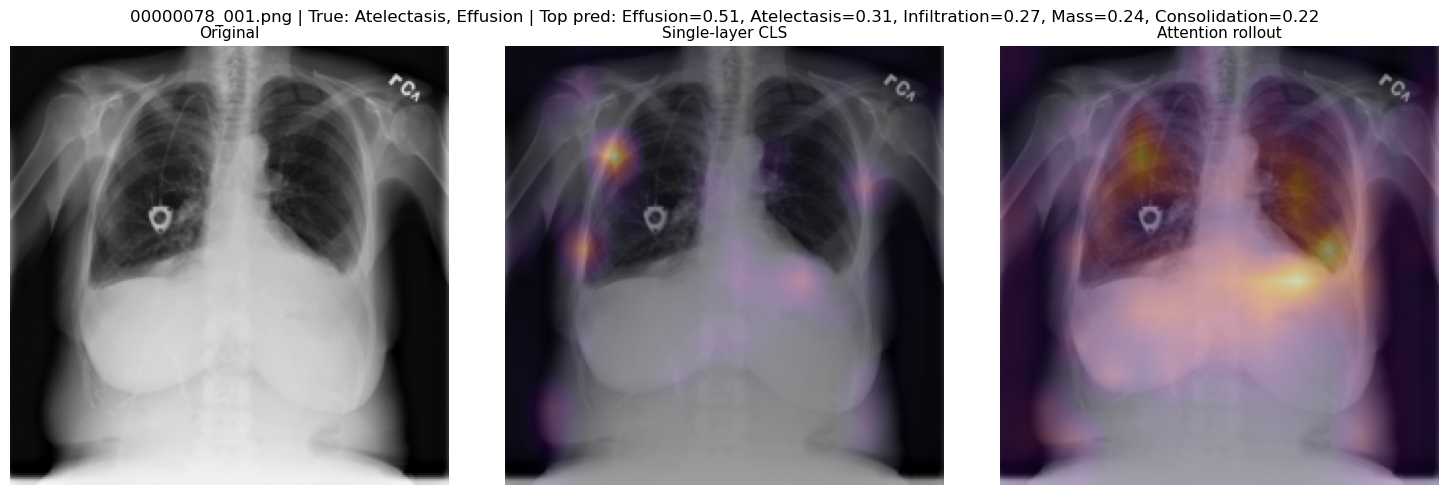

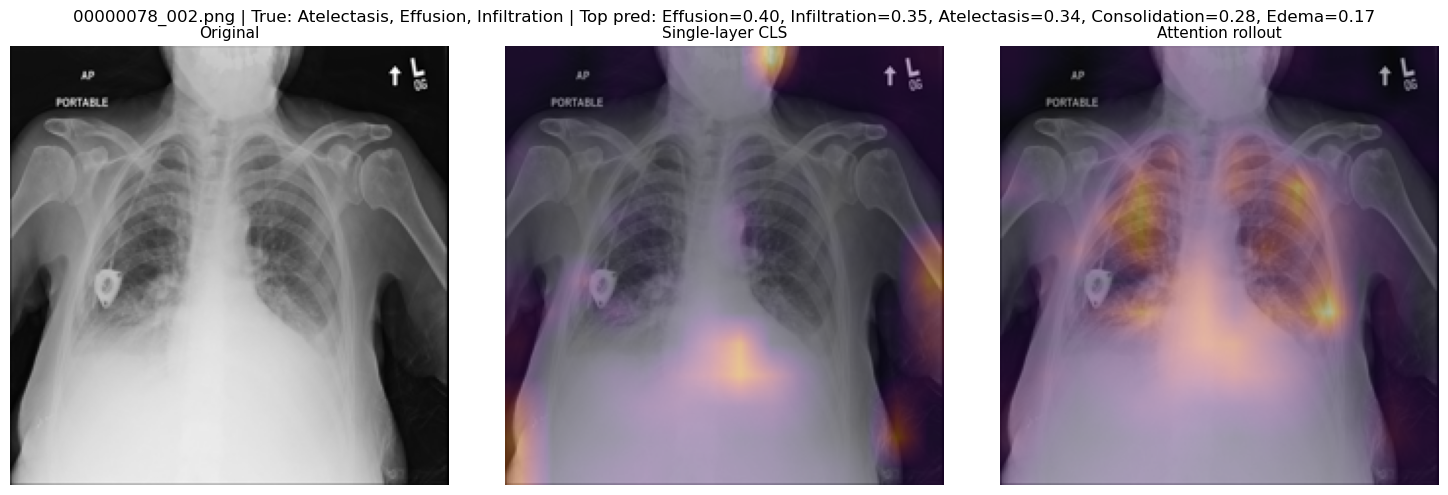

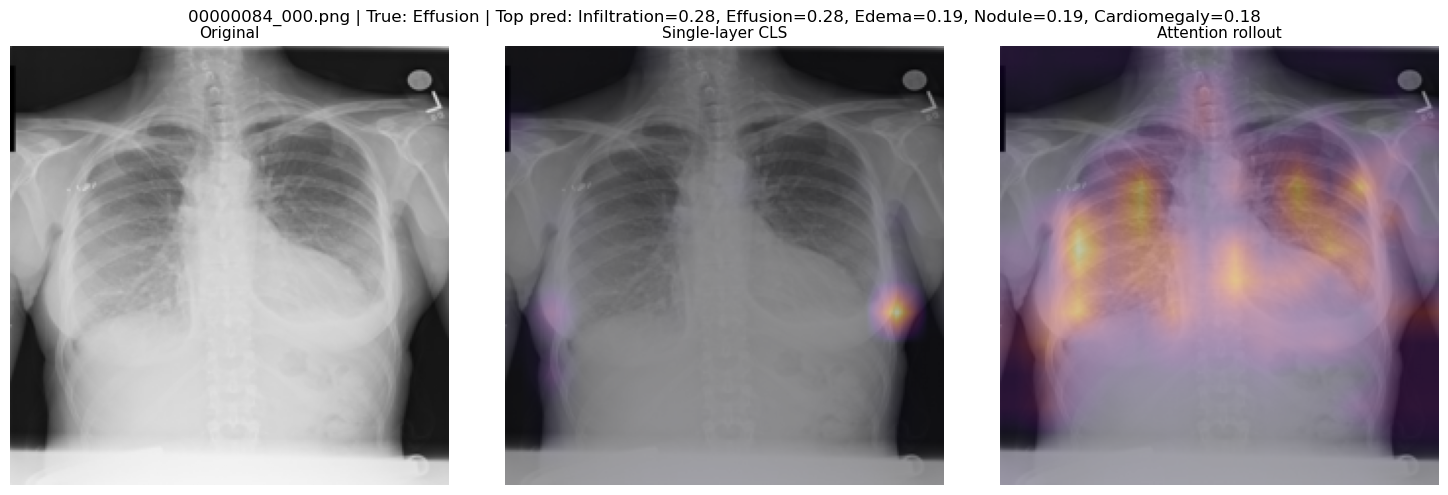

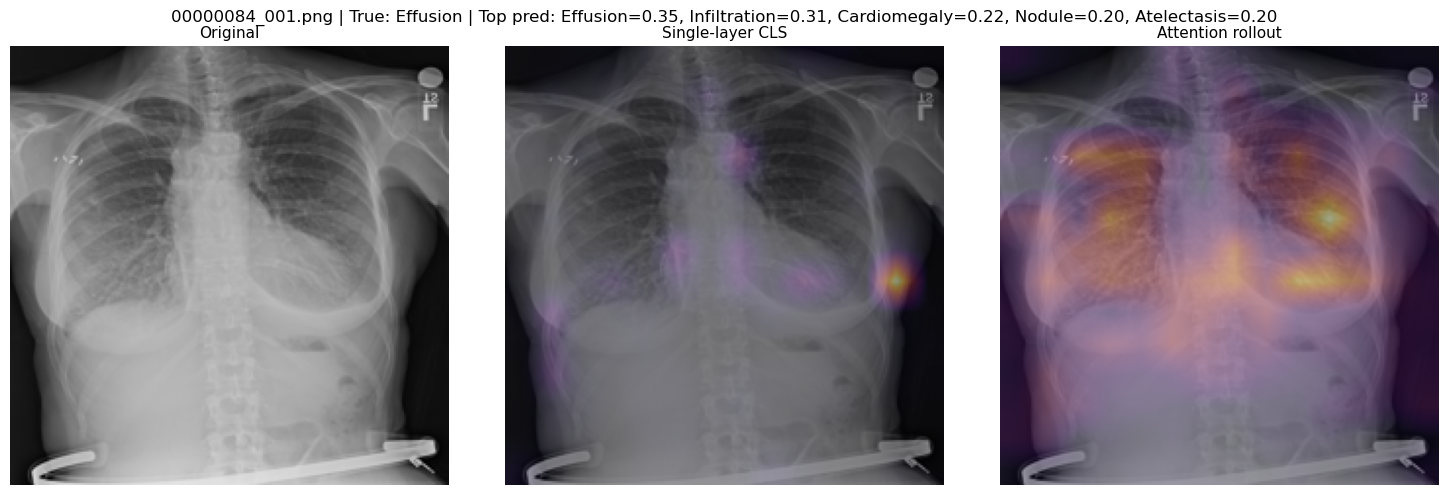

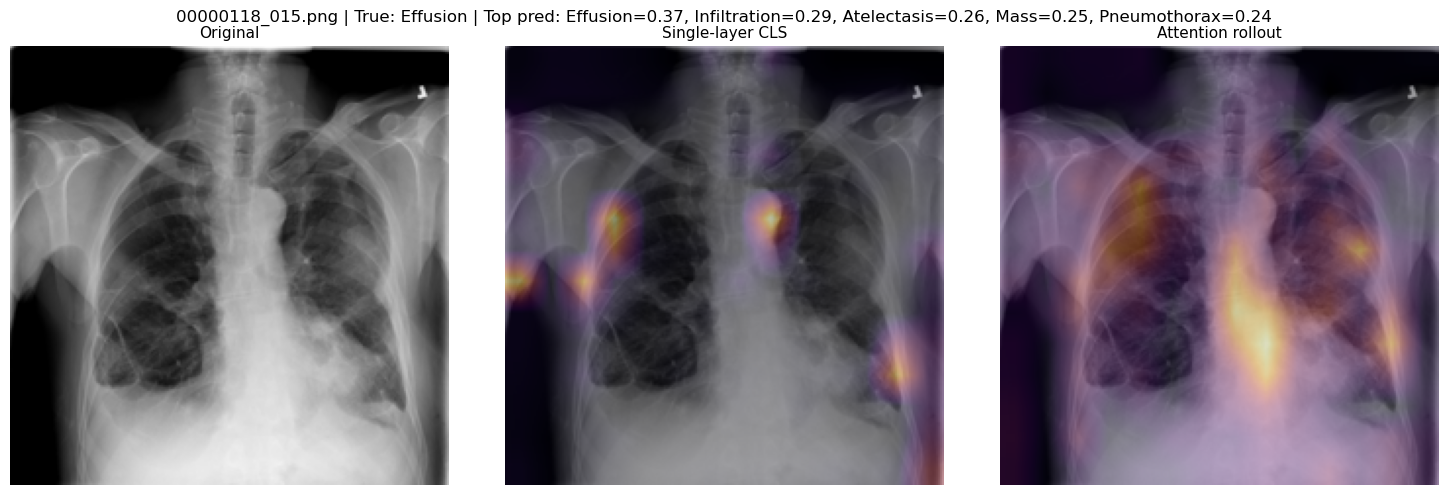

In [9]:
# Optionally scan the split for positive examples of a chosen label.
TARGET_LABEL = "Effusion"
MAX_SCAN_BATCHES = 20


def find_samples_with_label(data_loader, label_names, target_label, max_batches=20, max_samples=8):
    if target_label not in label_names:
        raise ValueError(f"Unknown target label '{target_label}'. Available labels: {label_names}")

    target_index = label_names.index(target_label)
    dataset_frame = getattr(data_loader.dataset, "frame", None)
    sample_offset = 0
    collected_images = []
    collected_labels = []
    collected_metadata = []

    for batch_index, (batch_images, batch_labels) in enumerate(data_loader):
        if batch_index >= max_batches or len(collected_images) >= max_samples:
            break

        batch_size = batch_images.size(0)
        batch_frame = None
        if dataset_frame is not None:
            batch_frame = dataset_frame.iloc[sample_offset : sample_offset + batch_size].reset_index(drop=True)
        sample_offset += batch_size

        positive_indices = (batch_labels[:, target_index] > 0.5).nonzero(as_tuple=False).flatten().tolist()
        for local_index in positive_indices:
            if len(collected_images) >= max_samples:
                break
            collected_images.append(batch_images[local_index].clone())
            collected_labels.append(batch_labels[local_index].clone())
            if batch_frame is not None:
                collected_metadata.append(batch_frame.iloc[local_index].to_dict())
            else:
                collected_metadata.append({})

    result_images = torch.stack(collected_images) if collected_images else torch.empty(0)
    result_labels = torch.stack(collected_labels) if collected_labels else torch.empty(0)
    return {
        "images": result_images,
        "labels": result_labels,
        "metadata": collected_metadata,
    }


positive_examples = find_samples_with_label(
    data_loader,
    label_names,
    TARGET_LABEL,
    max_batches=MAX_SCAN_BATCHES,
    max_samples=MAX_SAMPLES_TO_SHOW,
)

if positive_examples["images"].numel() == 0:
    print(f"No positive '{TARGET_LABEL}' examples found in the first {MAX_SCAN_BATCHES} batches of split={SPLIT}.")
else:
    positive_images = positive_examples["images"].to(device)
    positive_labels = positive_examples["labels"]
    positive_metadata = positive_examples["metadata"]

    with torch.inference_mode():
        positive_logits, positive_attn_maps = model(positive_images, return_attention=True)

    positive_attn_maps_cpu = [attention.detach().cpu() for attention in positive_attn_maps]
    _, positive_single_heatmaps = build_cls_attention_heatmap(
        positive_attn_maps_cpu,
        image_size=image_size,
        patch_size=patch_size,
        layer_index=LAYER_INDEX,
        head_reduction=HEAD_REDUCTION,
    )
    _, positive_rollout_heatmaps = rollout_to_heatmap(
        positive_attn_maps_cpu,
        image_size=image_size,
        patch_size=patch_size,
        head_reduction=ROLLOUT_HEAD_REDUCTION,
        discard_ratio=ROLLOUT_DISCARD_RATIO,
    )

    for sample_index in range(min(MAX_SAMPLES_TO_SHOW, positive_images.size(0))):
        image_array = denormalize_image(positive_images[sample_index].cpu(), mean, std)
        metadata = positive_metadata[sample_index] if sample_index < len(positive_metadata) else {}
        image_name = metadata.get("image_name", f"sample_{sample_index:03d}")
        true_labels = [label_names[idx] for idx, value in enumerate(positive_labels[sample_index].tolist()) if value > 0.5]
        true_label_text = ", ".join(true_labels) if true_labels else "None"
        top_predictions = get_top_labels(positive_logits[sample_index], label_names, k=5)
        top_prediction_text = ", ".join(f"{name}={score:.2f}" for name, score in top_predictions)
        title = f"{image_name} | True: {true_label_text} | Top pred: {top_prediction_text}"
        fig, _ = plot_heatmap_triplet(
            image_array,
            positive_single_heatmaps[sample_index],
            positive_rollout_heatmaps[sample_index],
            title=title,
        )
        plt.show()


In [23]:
import pandas as pd
 
df = pd.read_csv('data/annotations/BBox_List_2017.csv')
 
df = df.iloc[:, :-3]  # : 表示所有行,  :-3 表示除了最后3列以外的所有列
print(df.columns) 
df.to_csv('data/annotations/BBox_List_2017.csv', index=False)

Index(['Image Index', 'Finding Label', 'x', 'y', 'w', 'h'], dtype='object')


In [28]:
# Optional: overlay NIH bounding boxes when the CSV is available.
# We compute both bbox overlap (primary, visualization-friendly) and bbox IoU (secondary, stricter).
def load_bbox_frame(annotations_dir):
    annotations_dir = Path(annotations_dir)
    bbox_path = None
    for candidate in ("BBox_List_2017.csv", "BBox_list_2017.csv"):
        path = annotations_dir / candidate
        if path.exists():
            bbox_path = path
            break
    if bbox_path is None:
        return None

    frame = pd.read_csv(bbox_path)
    rename_map = {}
    for column in frame.columns:
        normalized = column.strip().lower()
        if normalized == "image index":
            rename_map[column] = "image_name"
        elif normalized == "finding label":
            rename_map[column] = "label"
        elif normalized == "bbox x":
            rename_map[column] = "x"
        elif normalized == "bbox y":
            rename_map[column] = "y"
        elif normalized == "bbox w":
            rename_map[column] = "w"
        elif normalized == "bbox h":
            rename_map[column] = "h"
    frame = frame.rename(columns=rename_map)
    required = {"image_name", "x", "y", "w", "h"}
    if not required.issubset(frame.columns):
        raise ValueError(f"Bounding box CSV is missing required columns: {required}")
    return frame


def get_boxes_for_image(bbox_frame, image_name):
    if bbox_frame is None:
        return None
    image_name = str(image_name)
    boxes = bbox_frame[bbox_frame["image_name"].astype(str) == image_name]
    return boxes if not boxes.empty else None


def draw_bboxes_on_axis(ax, boxes, image_size, original_width=1024, original_height=1024):
    if boxes is None or boxes.empty:
        return
    scale_x = image_size / max(float(original_width), 1.0)
    scale_y = image_size / max(float(original_height), 1.0)
    for _, row in boxes.iterrows():
        x = float(row["x"]) * scale_x
        y = float(row["y"]) * scale_y
        w = float(row["w"]) * scale_x
        h = float(row["h"]) * scale_y
        ax.add_patch(
            Rectangle((x, y), w, h, linewidth=1.5, edgecolor="cyan", facecolor="none")
        )


def compute_bbox_localization_metrics(
    heatmap,
    boxes,
    image_size,
    original_width=1024,
    original_height=1024,
    heatmap_percentile=80.0,
):
    if boxes is None or boxes.empty:
        return {
            "attention_bbox_overlap": float("nan"),
            "attention_bbox_iou": float("nan"),
        }

    heatmap_array = heatmap.detach().cpu().squeeze().numpy()
    threshold_value = float(np.percentile(heatmap_array, heatmap_percentile))
    attention_mask = heatmap_array >= threshold_value

    bbox_mask = np.zeros((image_size, image_size), dtype=bool)
    scale_x = image_size / max(float(original_width), 1.0)
    scale_y = image_size / max(float(original_height), 1.0)
    for _, row in boxes.iterrows():
        x0 = max(0, int(np.floor(float(row["x"]) * scale_x)))
        y0 = max(0, int(np.floor(float(row["y"]) * scale_y)))
        x1 = min(image_size, int(np.ceil((float(row["x"]) + float(row["w"])) * scale_x)))
        y1 = min(image_size, int(np.ceil((float(row["y"]) + float(row["h"])) * scale_y)))
        if x1 > x0 and y1 > y0:
            bbox_mask[y0:y1, x0:x1] = True

    intersection = np.logical_and(attention_mask, bbox_mask).sum()
    union = np.logical_or(attention_mask, bbox_mask).sum()
    bbox_area = bbox_mask.sum()

    return {
        "attention_bbox_iou": float(intersection / union) if union > 0 else float("nan"),
        "attention_bbox_overlap": float(intersection / bbox_area) if bbox_area > 0 else float("nan"),
    }


bbox_frame = load_bbox_frame(config["data"]["annotations_dir"])
bbox_heatmap_percentile = 80.0
if bbox_frame is None:
    print("No NIH bounding-box CSV found under annotations_dir. Skipping bbox preview.")
elif batch_frame is None:
    print("No dataset frame metadata available for the current batch. Skipping bbox preview.")
else:
    preview_index = None
    preview_boxes = None
    preview_row = None
    for sample_index in range(min(len(batch_frame), images.size(0))):
        row = batch_frame.iloc[sample_index]
        boxes = get_boxes_for_image(bbox_frame, row.get("image_name"))
        if boxes is not None:
            preview_index = sample_index
            preview_boxes = boxes
            preview_row = row
            break

    if preview_index is None:
        print("No bounding-box match found in the current batch.")
    else:
        image_array = denormalize_image(images[preview_index].cpu(), mean, std)
        single_overlay = overlay_heatmap(image_array, single_layer_heatmaps[preview_index])
        rollout_overlay = overlay_heatmap(image_array, rollout_heatmaps[preview_index])
        original_width = float(preview_row.get("original_width", 1024) or 1024)
        original_height = float(preview_row.get("original_height", 1024) or 1024)

        single_metrics = compute_bbox_localization_metrics(
            single_layer_heatmaps[preview_index],
            preview_boxes,
            image_size=image_size,
            original_width=original_width,
            original_height=original_height,
            heatmap_percentile=bbox_heatmap_percentile,
        )
        rollout_metrics = compute_bbox_localization_metrics(
            rollout_heatmaps[preview_index],
            preview_boxes,
            image_size=image_size,
            original_width=original_width,
            original_height=original_height,
            heatmap_percentile=bbox_heatmap_percentile,
        )

        print("Single-layer CLS attention:")
        print(f"- bbox overlap: {single_metrics['attention_bbox_overlap']:.4f}")
        print(f"- bbox IoU: {single_metrics['attention_bbox_iou']:.4f}")
        print()
        print("Attention rollout:")
        print(f"- bbox overlap: {rollout_metrics['attention_bbox_overlap']:.4f}")
        print(f"- bbox IoU: {rollout_metrics['attention_bbox_iou']:.4f}")

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(image_array)
        axes[0].set_title("Original + bbox")
        axes[1].imshow(single_overlay)
        axes[1].set_title(
            "Single-layer CLS + bbox\n"
            f"bbox overlap: {single_metrics['attention_bbox_overlap']:.3f} | "
            f"bbox IoU: {single_metrics['attention_bbox_iou']:.3f}"
        )
        axes[2].imshow(rollout_overlay)
        axes[2].set_title(
            "Attention rollout + bbox\n"
            f"bbox overlap: {rollout_metrics['attention_bbox_overlap']:.3f} | "
            f"bbox IoU: {rollout_metrics['attention_bbox_iou']:.3f}"
        )
        for axis in axes:
            draw_bboxes_on_axis(
                axis,
                preview_boxes,
                image_size=image_size,
                original_width=original_width,
                original_height=original_height,
            )
            axis.axis("off")
        fig.suptitle(
            f"BBox preview: {preview_row.get('image_name', f'sample_{preview_index:03d}')} | "
            "bbox overlap is the primary localization metric here"
        )
        fig.tight_layout()
        plt.show()


No bounding-box match found in the current batch.


In [25]:
# Save a small set of visualization PNGs and a companion CSV for later review.
output_dir = REPO_ROOT / "artifacts/interpretability_notebook"
output_dir.mkdir(parents=True, exist_ok=True)

records = []
samples_to_save = min(MAX_SAMPLES_TO_SHOW, images.size(0))
for sample_index in range(samples_to_save):
    image_array = denormalize_image(images[sample_index].cpu(), mean, std)
    true_labels = [label_names[idx] for idx, value in enumerate(labels[sample_index].tolist()) if value > 0.5]
    true_label_text = ", ".join(true_labels) if true_labels else "None"
    top_predictions = get_top_labels(logits[sample_index], label_names, k=5)
    top_prediction_text = ", ".join(f"{name}={score:.3f}" for name, score in top_predictions)
    title = f"Sample {sample_index} | True: {true_label_text} | Top pred: {top_prediction_text}"
    fig, _ = plot_heatmap_triplet(
        image_array,
        single_layer_heatmaps[sample_index],
        rollout_heatmaps[sample_index],
        title=title,
    )

    output_path = output_dir / f"sample_{sample_index:03d}_attention_comparison.png"
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

    image_name = None
    if batch_frame is not None and sample_index < len(batch_frame):
        image_name = batch_frame.iloc[sample_index].get("image_name")

    records.append(
        {
            "sample_index": sample_index,
            "image_name": image_name,
            "true_labels": true_label_text,
            "top_predictions": top_prediction_text,
            "output_png_path": str(output_path),
        }
    )

visualized_samples_path = output_dir / "visualized_samples.csv"
pd.DataFrame(records).to_csv(visualized_samples_path, index=False)

print(f"Saved {len(records)} visualization PNGs to {output_dir}")
print(f"Saved sample manifest to {visualized_samples_path}")


Saved 8 visualization PNGs to /home/nate/Documents/omscs/dl/final_project/visiontrans_diagnostics/artifacts/interpretability_notebook
Saved sample manifest to /home/nate/Documents/omscs/dl/final_project/visiontrans_diagnostics/artifacts/interpretability_notebook/visualized_samples.csv
